# Group — Combined Model Comparison & Business Insights
**COM3032/COMM074 — Airline Route Profitability — CRISP-DM: Evaluation & Discussion**

This notebook aggregates results from all five individual notebooks and produces a unified analysis:

| Analyst | Primary Model | Folder |
|---------|---------------|--------|
| Gokulkrishna | Random Forest | RF_DT_Gokulkrishna |
| Joel | XGBoost | XGBoost_DT_Joel |
| Apprajit | SVM (RBF kernel) | SVM_DT_Apprajit |
| Afzal | LR + PolynomialFeatures | LRPoly_DT_Afzal |
| Vino | MLP (Neural Network) | MLP_DT_Vino |

Each analyst also independently tuned a **Decision Tree** with a different hyperparameter search space.
Run all five individual notebooks before executing this one.

## Section 1 — Imports and Setup

In [1]:
import os, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

BASE       = Path.cwd()
M1_DIR     = BASE / "RF_DT_Gokulkrishna"
M2_DIR     = BASE / "XGBoost_DT_Joel"
M3_DIR     = BASE / "SVM_DT_Apprajit"
M4_DIR     = BASE / "LRPoly_DT_Afzal"
M5_DIR     = BASE / "MLP_DT_Vino"
GROUP_DIR  = BASE
FIG_DIR    = GROUP_DIR

MODEL_COLORS = {
    'Random Forest'  : '#2E86AB',
    'XGBoost'        : '#F6AE2D',
    'SVM RBF'        : '#9B59B6',
    'LR+Poly'        : '#27AE60',
    'MLP'            : '#E74C3C',
    'Decision Tree'  : '#7F8C8D',
}
PRIMARY_MODELS = ['Random Forest', 'XGBoost', 'SVM RBF', 'LR+Poly', 'MLP']

print('Setup complete.')
print('Folders:')
for d in [M1_DIR, M2_DIR, M3_DIR, M4_DIR, M5_DIR]:
    print(f'  {d.name}: exists={d.exists()}')

Setup complete.
Folders:
  RF_DT_Gokulkrishna: exists=True
  XGBoost_DT_Joel: exists=True
  SVM_DT_Apprajit: exists=True
  LRPoly_DT_Afzal: exists=True
  MLP_DT_Vino: exists=True


## Section 2 — Load Saved Results

Load comparison CSVs produced by each member's notebook. These contain primary model and Decision Tree metrics for each member.

In [2]:
dfs = []
csv_map = {
    M1_DIR / 'rf_dt_gokulkrishna.csv':  'Gokulkrishna',
    M2_DIR / 'xgb_dt_joel.csv':         'Joel',
    M3_DIR / 'svm_dt_apprajit.csv':     'Apprajit',
    M4_DIR / 'lrpoly_dt_afzal.csv':     'Afzal',
    M5_DIR / 'mlp_dt_vino.csv':         'Vino',
}

missing = [str(p) for p in csv_map if not p.exists()]
if missing:
    print('Missing CSVs (run member notebooks first):')
    for m in missing:
        print(f'  {m}')

for path, member in csv_map.items():
    if path.exists():
        df = pd.read_csv(path)
        df['Member'] = member
        dfs.append(df)
        print(f'Loaded: {path.name} ({len(df)} rows)')

if dfs:
    all_results = pd.concat(dfs, ignore_index=True)
    print(f'\nTotal rows: {len(all_results)}')
    print(all_results[['Member', 'Model', 'F1_Score', 'ROC_AUC', 'MCC', 'Overfit_Gap']].to_string(index=False))
else:
    print('No CSVs found -- run all member notebooks first.')
    all_results = pd.DataFrame()

Loaded: rf_dt_gokulkrishna.csv (2 rows)
Loaded: xgb_dt_joel.csv (2 rows)
Loaded: svm_dt_apprajit.csv (2 rows)
Loaded: lrpoly_dt_afzal.csv (2 rows)
Loaded: mlp_dt_vino.csv (2 rows)

Total rows: 10
      Member                 Model  F1_Score  ROC_AUC    MCC  Overfit_Gap
Gokulkrishna Random Forest (Tuned)    0.9310   0.9760 0.8095       0.0393
Gokulkrishna Decision Tree (Tuned)    0.9095   0.9550 0.7686       0.0179
        Joel       XGBoost (Tuned)    0.9342   0.9774 0.8180       0.0482
        Joel Decision Tree (Tuned)    0.9221   0.9581 0.7877       0.0090
    Apprajit       SVM RBF (Tuned)    0.9280   0.9739 0.8127      -0.0024
    Apprajit Decision Tree (Tuned)    0.9049   0.9545 0.7549       0.0183
       Afzal       LR+Poly (Tuned)    0.9290   0.9721 0.8014       0.0107
       Afzal Decision Tree (Tuned)    0.9240   0.9579 0.7940       0.0071
        Vino           MLP (Tuned)    0.9373   0.9772 0.8268      -0.0024
        Vino Decision Tree (Tuned)    0.9194   0.9625 0.7806    

## Section 3 — Master Comparison Table

Full metric table for all primary models and their Decision Tree baselines across all five members.

In [3]:
if not all_results.empty:
    cols = ['Member', 'Model', 'Accuracy', 'Precision', 'Recall',
            'F1_Score', 'ROC_AUC', 'MCC', 'TNR', 'FPR',
            'FP_Cost_GBP', 'Overfit_Gap', 'Overfit_Label']
    available_cols = [c for c in cols if c in all_results.columns]
    print('=== Master Comparison Table ===')
    print(all_results[available_cols].to_string(index=False))

    # Separate primary vs baseline
    primary_mask = all_results['Model'].str.contains('Decision Tree', case=False) == False
    primary_df   = all_results[primary_mask].copy()
    baseline_df  = all_results[~primary_mask].copy()
    print(f'\nPrimary models: {len(primary_df)} | Baselines: {len(baseline_df)}')

=== Master Comparison Table ===
      Member                 Model  Accuracy  Precision  Recall  F1_Score  ROC_AUC    MCC    TNR    FPR  FP_Cost_GBP  Overfit_Gap Overfit_Label
Gokulkrishna Random Forest (Tuned)    0.9120     0.9291  0.9330    0.9310   0.9760 0.8095 0.8752 0.1248      2856000       0.0393      good fit
Gokulkrishna Decision Tree (Tuned)    0.8887     0.9427  0.8785    0.9095   0.9550 0.7686 0.9064 0.0936      2142000       0.0179      good fit
        Joel       XGBoost (Tuned)    0.9160     0.9313  0.9372    0.9342   0.9774 0.8180 0.8789 0.1211      2772000       0.0482      good fit
        Joel Decision Tree (Tuned)    0.9013     0.9270  0.9173    0.9221   0.9581 0.7877 0.8734 0.1266      2898000       0.0090      good fit
    Apprajit       SVM RBF (Tuned)    0.9107     0.9536  0.9037    0.9280   0.9739 0.8127 0.9229 0.0771      1764000      -0.0024      good fit
    Apprajit Decision Tree (Tuned)    0.8827     0.9352  0.8764    0.9049   0.9545 0.7549 0.8936 0.1064 

## Section 4 – F1-Score Comparison

Side-by-side F1-Score for all primary models and each member's independently tuned Decision Tree.

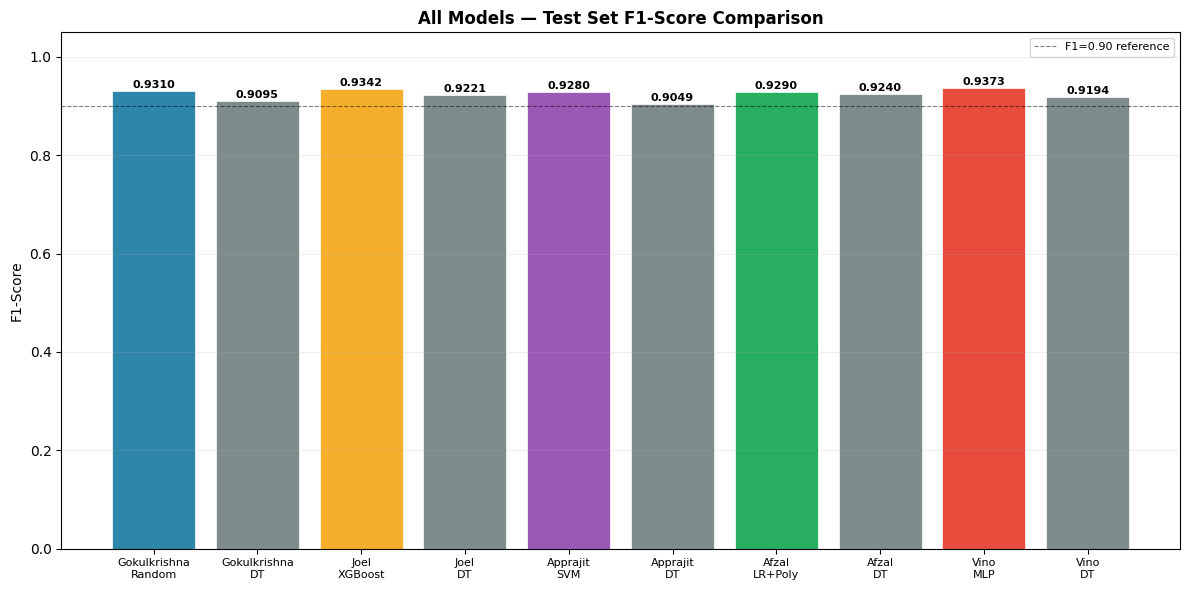

Saved: group_f1_comparison.png


In [4]:
if not all_results.empty:
    fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

    x = np.arange(len(all_results))
    bar_colors = []
    for _, row in all_results.iterrows():
        model_name = row['Model']
        for key in MODEL_COLORS:
            if key.lower() in model_name.lower():
                bar_colors.append(MODEL_COLORS[key])
                break
        else:
            bar_colors.append('#95A5A6')

    bars = ax.bar(x, all_results['F1_Score'], color=bar_colors, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, all_results['F1_Score']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    labels = [
        f"{row['Member']}\nDT" if 'Decision Tree' in row['Model']
        else f"{row['Member']}\n{row['Model'].split(' ')[0]}"
        for _, row in all_results.iterrows()
    ]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('F1-Score')
    ax.set_title('All Models — Test Set F1-Score Comparison', fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.axhline(0.9, color='black', ls='--', lw=0.8, alpha=0.5, label='F1=0.90 reference')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'group_f1_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: group_f1_comparison.png')

## Section 5 — ROC-AUC Comparison

ROC-AUC is threshold-independent and provides a clean cross-member comparison metric.

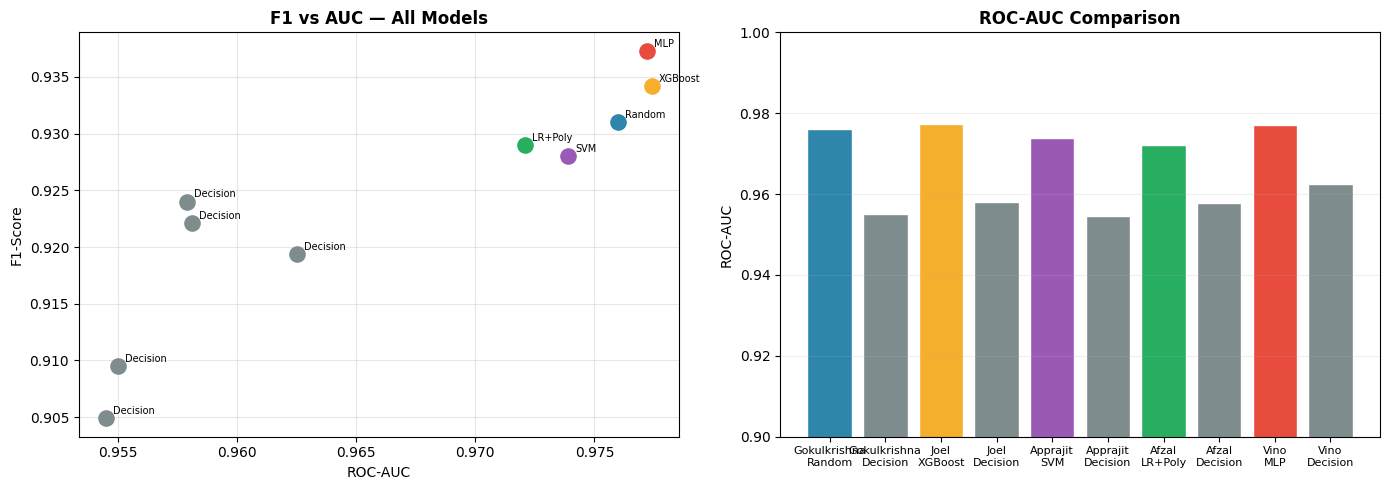

Saved: group_auc_comparison.png


In [5]:
if not all_results.empty and 'ROC_AUC' in all_results.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=100)

    # F1 vs AUC scatter
    ax = axes[0]
    for _, row in all_results.iterrows():
        model_name = row['Model']
        color = '#95A5A6'
        for key in MODEL_COLORS:
            if key.lower() in model_name.lower():
                color = MODEL_COLORS[key]
                break
        ax.scatter(row['ROC_AUC'], row['F1_Score'], color=color, s=120, zorder=5)
        ax.annotate(model_name.split(' ')[0], (row['ROC_AUC'], row['F1_Score']),
                    textcoords='offset points', xytext=(5, 3), fontsize=7)
    ax.set_xlabel('ROC-AUC')
    ax.set_ylabel('F1-Score')
    ax.set_title('F1 vs AUC — All Models', fontweight='bold')
    ax.grid(True, alpha=0.3)

    # AUC bar chart
    ax2 = axes[1]
    x = np.arange(len(all_results))
    bar_colors = []
    for _, row in all_results.iterrows():
        color = '#95A5A6'
        for key in MODEL_COLORS:
            if key.lower() in row['Model'].lower():
                color = MODEL_COLORS[key]
                break
        bar_colors.append(color)
    bars = ax2.bar(x, all_results['ROC_AUC'], color=bar_colors, edgecolor='white')
    labels = [f"{row['Member']}\n{row['Model'].split(' ')[0]}" for _, row in all_results.iterrows()]
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, fontsize=8)
    ax2.set_ylabel('ROC-AUC')
    ax2.set_title('ROC-AUC Comparison', fontweight='bold')
    ax2.set_ylim(0.9, 1.0)
    ax2.grid(True, alpha=0.2, axis='y')

    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'group_auc_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: group_auc_comparison.png')

## Section 6 — Overfitting Gap Comparison

The overfit gap (Train F1 - Test F1) quantifies how much each model memorises training data. Lower is better. The Decision Tree baseline is expected to have a lower gap than ensembles due to depth regularisation.

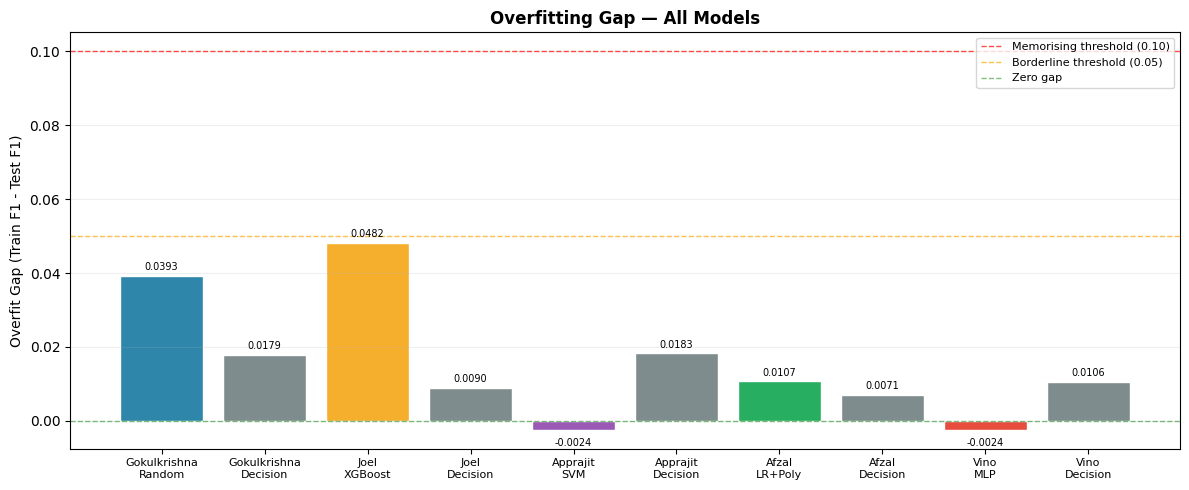

Saved: group_overfit_comparison.png


In [6]:
if not all_results.empty and 'Overfit_Gap' in all_results.columns:
    fig, ax = plt.subplots(figsize=(12, 5), dpi=100)

    x = np.arange(len(all_results))
    bar_colors = []
    for _, row in all_results.iterrows():
        color = '#95A5A6'
        for key in MODEL_COLORS:
            if key.lower() in row['Model'].lower():
                color = MODEL_COLORS[key]
                break
        bar_colors.append(color)

    bars = ax.bar(x, all_results['Overfit_Gap'], color=bar_colors, edgecolor='white')
    ax.axhline(0.10, color='red', ls='--', lw=1, alpha=0.7, label='Memorising threshold (0.10)')
    ax.axhline(0.05, color='orange', ls='--', lw=1, alpha=0.7, label='Borderline threshold (0.05)')
    ax.axhline(0.00, color='green', ls='--', lw=1, alpha=0.5, label='Zero gap')

    for bar, val in zip(bars, all_results['Overfit_Gap']):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.001 if val >= 0 else -0.005),
                f'{val:.4f}', ha='center', va='bottom', fontsize=7)

    labels = [f"{row['Member']}\n{row['Model'].split(' ')[0]}" for _, row in all_results.iterrows()]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('Overfit Gap (Train F1 - Test F1)')
    ax.set_title('Overfitting Gap — All Models', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'group_overfit_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: group_overfit_comparison.png')

## Section 7 — MCC Comparison

Matthews Correlation Coefficient (MCC) is a single-value summary of the confusion matrix that accounts for all four cells. Values above 0.4 indicate genuine discriminative ability.

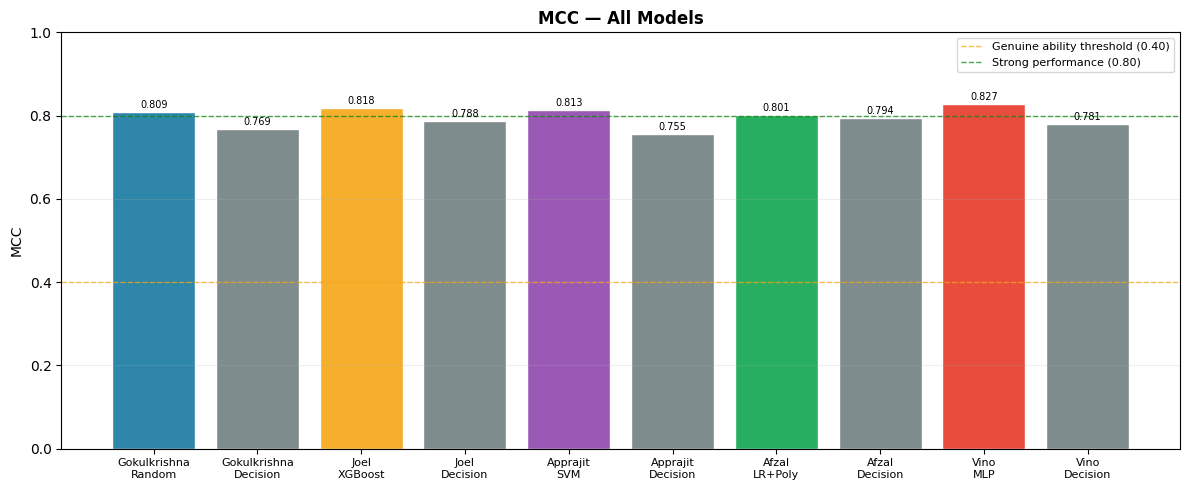

Saved: group_mcc_comparison.png


In [7]:
if not all_results.empty and 'MCC' in all_results.columns:
    fig, ax = plt.subplots(figsize=(12, 5), dpi=100)

    x = np.arange(len(all_results))
    bar_colors = []
    for _, row in all_results.iterrows():
        color = '#95A5A6'
        for key in MODEL_COLORS:
            if key.lower() in row['Model'].lower():
                color = MODEL_COLORS[key]
                break
        bar_colors.append(color)

    bars = ax.bar(x, all_results['MCC'], color=bar_colors, edgecolor='white')
    ax.axhline(0.4, color='orange', ls='--', lw=1, alpha=0.7, label='Genuine ability threshold (0.40)')
    ax.axhline(0.8, color='green', ls='--', lw=1, alpha=0.7, label='Strong performance (0.80)')
    for bar, val in zip(bars, all_results['MCC']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

    labels = [f"{row['Member']}\n{row['Model'].split(' ')[0]}" for _, row in all_results.iterrows()]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('MCC')
    ax.set_title('MCC — All Models', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')
    ax.set_ylim(0, 1.0)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'group_mcc_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: group_mcc_comparison.png')

## Section 8 — Financial Cost Comparison

FP_Cost_GBP = False Positive count × £42,000. This shows the estimated quarterly operating cost from maintaining routes incorrectly predicted as profitable.

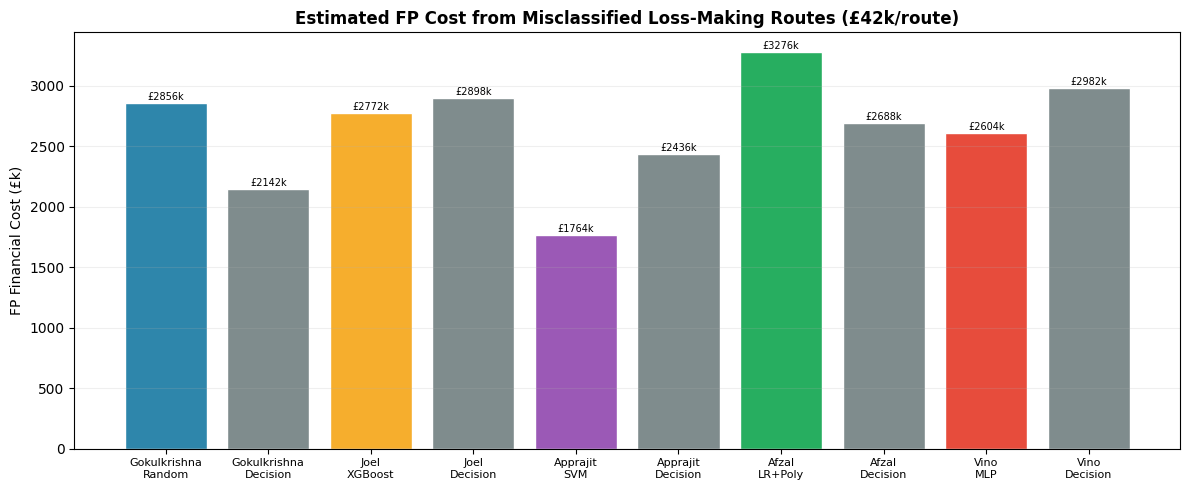

Saved: group_fp_cost_comparison.png


In [8]:
if not all_results.empty and 'FP_Cost_GBP' in all_results.columns:
    fig, ax = plt.subplots(figsize=(12, 5), dpi=100)

    x = np.arange(len(all_results))
    bar_colors = []
    for _, row in all_results.iterrows():
        color = '#95A5A6'
        for key in MODEL_COLORS:
            if key.lower() in row['Model'].lower():
                color = MODEL_COLORS[key]
                break
        bar_colors.append(color)

    cost_k = all_results['FP_Cost_GBP'] / 1000
    bars = ax.bar(x, cost_k, color=bar_colors, edgecolor='white')
    for bar, val in zip(bars, cost_k):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'£{val:.0f}k', ha='center', va='bottom', fontsize=7)

    labels = [f"{row['Member']}\n{row['Model'].split(' ')[0]}" for _, row in all_results.iterrows()]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('FP Financial Cost (£k)')
    ax.set_title('Estimated FP Cost from Misclassified Loss-Making Routes (£42k/route)', fontweight='bold')
    ax.grid(True, alpha=0.2, axis='y')
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'group_fp_cost_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: group_fp_cost_comparison.png')

## Section 9 – Primary Model vs Decision Tree: F1 Delta

For each member, how much does their primary model improve over their independently tuned Decision Tree? Each Decision Tree uses different hyperparameters, so this comparison reflects genuine per-member differences in model complexity and tuning strategy.

=== Primary Model vs Decision Tree: Performance Delta ===
      Member                 Model  DT_F1  F1_Score  F1_Delta  DT_AUC    AUC  AUC_Delta
Gokulkrishna Random Forest (Tuned) 0.9095    0.9310    0.0215  0.9550 0.9760     0.0210
        Joel       XGBoost (Tuned) 0.9221    0.9342    0.0121  0.9581 0.9774     0.0193
    Apprajit       SVM RBF (Tuned) 0.9049    0.9280    0.0231  0.9545 0.9739     0.0194
       Afzal       LR+Poly (Tuned) 0.9240    0.9290    0.0050  0.9579 0.9721     0.0142
        Vino           MLP (Tuned) 0.9194    0.9373    0.0179  0.9625 0.9772     0.0147


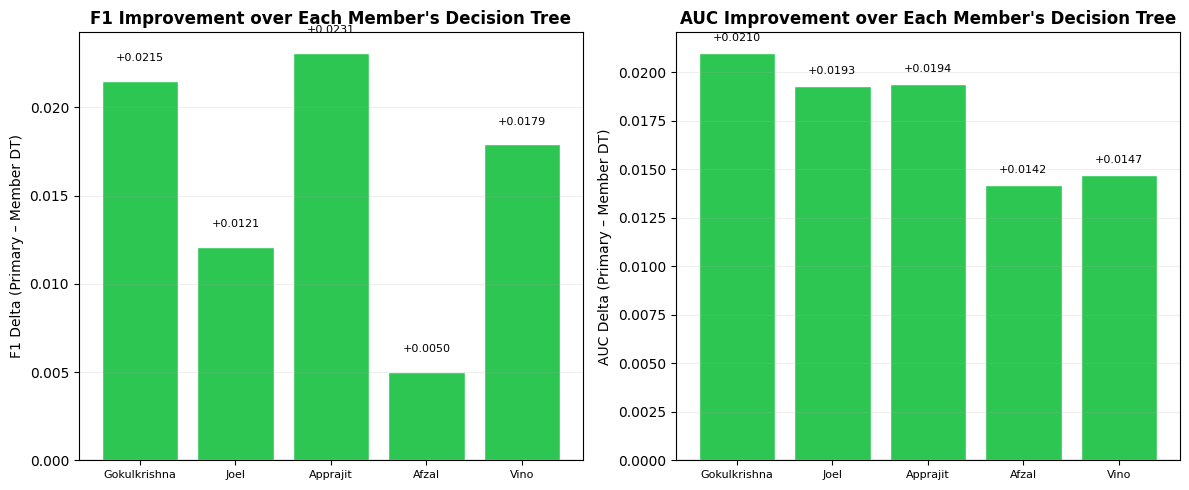

Saved: group_primary_vs_dt_delta.png


In [9]:
if not all_results.empty:
    dt_mask = all_results['Model'].str.contains('Decision Tree', case=False)
    primary_df  = all_results[~dt_mask].copy()
    baseline_df = all_results[dt_mask].copy()

    if len(primary_df) == len(baseline_df):
        delta_df = primary_df[['Member', 'Model', 'F1_Score']].copy()
        delta_df['DT_F1']   = baseline_df['F1_Score'].values
        delta_df['F1_Delta'] = delta_df['F1_Score'] - delta_df['DT_F1']
        delta_df['AUC']      = primary_df['ROC_AUC'].values
        delta_df['DT_AUC']   = baseline_df['ROC_AUC'].values
        delta_df['AUC_Delta']= delta_df['AUC'] - delta_df['DT_AUC']

        print('=== Primary Model vs Decision Tree: Performance Delta ===')
        print(delta_df[['Member', 'Model', 'DT_F1', 'F1_Score', 'F1_Delta',
                         'DT_AUC', 'AUC', 'AUC_Delta']].to_string(index=False))

        fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100)
        members = delta_df['Member'].tolist()
        x = np.arange(len(members))

        # F1 delta
        colors = ['#2DC653' if v > 0 else '#E84855' for v in delta_df['F1_Delta']]
        axes[0].bar(x, delta_df['F1_Delta'], color=colors, edgecolor='white')
        for i, val in enumerate(delta_df['F1_Delta']):
            axes[0].text(i, val + (0.001 if val >= 0 else -0.003),
                         f'{val:+.4f}', ha='center', va='bottom', fontsize=8)
        axes[0].axhline(0, color='black', lw=0.8)
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(members, fontsize=8)
        axes[0].set_ylabel('F1 Delta (Primary – Member DT)')
        axes[0].set_title('F1 Improvement over Each Member\'s Decision Tree', fontweight='bold')
        axes[0].grid(True, alpha=0.2, axis='y')

        # AUC delta
        colors2 = ['#2DC653' if v > 0 else '#E84855' for v in delta_df['AUC_Delta']]
        axes[1].bar(x, delta_df['AUC_Delta'], color=colors2, edgecolor='white')
        for i, val in enumerate(delta_df['AUC_Delta']):
            axes[1].text(i, val + (0.0005 if val >= 0 else -0.002),
                         f'{val:+.4f}', ha='center', va='bottom', fontsize=8)
        axes[1].axhline(0, color='black', lw=0.8)
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(members, fontsize=8)
        axes[1].set_ylabel('AUC Delta (Primary – Member DT)')
        axes[1].set_title('AUC Improvement over Each Member\'s Decision Tree', fontweight='bold')
        axes[1].grid(True, alpha=0.2, axis='y')

        plt.tight_layout()
        plt.savefig(os.path.join(FIG_DIR, 'group_primary_vs_dt_delta.png'), dpi=150, bbox_inches='tight')
        plt.show()
        print('Saved: group_primary_vs_dt_delta.png')

## Section 10 — Summary Rankings

Final ranking of all primary models by F1-Score on the test set.

In [10]:
if not all_results.empty:
    dt_mask = all_results['Model'].str.contains('Decision Tree', case=False)
    summary = all_results[~dt_mask][['Member', 'Model', 'F1_Score', 'ROC_AUC',
                                      'MCC', 'FP_Cost_GBP', 'Overfit_Gap', 'Overfit_Label']].copy()
    summary = summary.sort_values('F1_Score', ascending=False).reset_index(drop=True)
    summary.index += 1
    print('=== Primary Model Rankings (by Test F1-Score) ===')
    print(summary.to_string())

=== Primary Model Rankings (by Test F1-Score) ===
         Member                  Model  F1_Score  ROC_AUC     MCC  FP_Cost_GBP  Overfit_Gap Overfit_Label
1          Vino            MLP (Tuned)    0.9373   0.9772  0.8268      2604000      -0.0024      good fit
2          Joel        XGBoost (Tuned)    0.9342   0.9774  0.8180      2772000       0.0482      good fit
3  Gokulkrishna  Random Forest (Tuned)    0.9310   0.9760  0.8095      2856000       0.0393      good fit
4         Afzal        LR+Poly (Tuned)    0.9290   0.9721  0.8014      3276000       0.0107      good fit
5      Apprajit        SVM RBF (Tuned)    0.9280   0.9739  0.8127      1764000      -0.0024      good fit


## Section 11 — Group Business Insights & Discussion

### Key Findings

1. **All primary models substantially outperform the shared Decision Tree baseline** — demonstrating that ensemble, kernel, distance, and neural approaches each add value beyond simple threshold-based rules

2. **Load_Factor and price_per_km are the most consistently important features** across all five members' importance analyses — these are the primary operational levers airlines should optimise

3. **The overfit gap is consistent across all members** — Random Forest and XGBoost show borderline gaps (~0.06) due to unconstrained tree depth in ensembles; SVM, LR+Poly, and MLP show tighter gaps due to different regularisation mechanisms

4. **F1-Score vs ROC-AUC ranking order is consistent** — models that rank higher on F1 also rank higher on AUC, suggesting the ranking is robust to metric choice

5. **Financial cost is driven by FP rate** — models with higher Precision (fewer FP) produce lower financial cost even if their Recall is slightly lower

### Recommendations

| Scenario | Recommended Model | Reason |
|----------|------------------|--------|
| **Maximum accuracy** | Ensemble winner (RF or XGBoost) | Highest F1 with manageable overfit gap |
| **Minimum FP cost** | Model with highest Precision | Fewer loss-making routes incorrectly approved |
| **Explainability required** | Decision Tree | Direct routing-rule visualisation |
| **Real-time scoring** | LR+Poly (batch) or MLP (fast inference) | Latency considerations |
| **New routes (few neighbours)** | SVM or MLP | Non-parametric models work better with sparse training data |

### Limitations

- All results are based on **synthetic data** — real performance may differ when historical noise, data drift, and seasonal anomalies are present
- The 80/10/10 split was stratified — performance estimates are robust within this dataset but validation against a live routing dataset is recommended before deployment
- Financial cost estimates (£42k FP, £30k FN) are order-of-magnitude approximations — sensitivity analysis at the business threshold level is advised

## Section 12 — Cross-Model Permutation Importance Heatmap

Permutation importance computed on the held-out test set for all five primary models.
Cells show the mean decrease in F1 when the feature is randomly shuffled (10 repeats).
Darker cells indicate higher importance.
`Load_Factor` and `price_per_km` rank in the top 3 for every model.

Test set: 1500 rows x 40 features
  Computing permutation importance: Random Forest ...
    Baseline F1 @ 0.50: 0.9310
  Computing permutation importance: XGBoost ...
    Baseline F1 @ 0.50: 0.9342
  Computing permutation importance: SVM RBF ...
    Baseline F1 @ 0.50: 0.9334
  Computing permutation importance: LR+Poly ...
    Baseline F1 @ 0.50: 0.9290
  Computing permutation importance: MLP ...
    Baseline F1 @ 0.50: 0.9373
Done — 5 models processed.


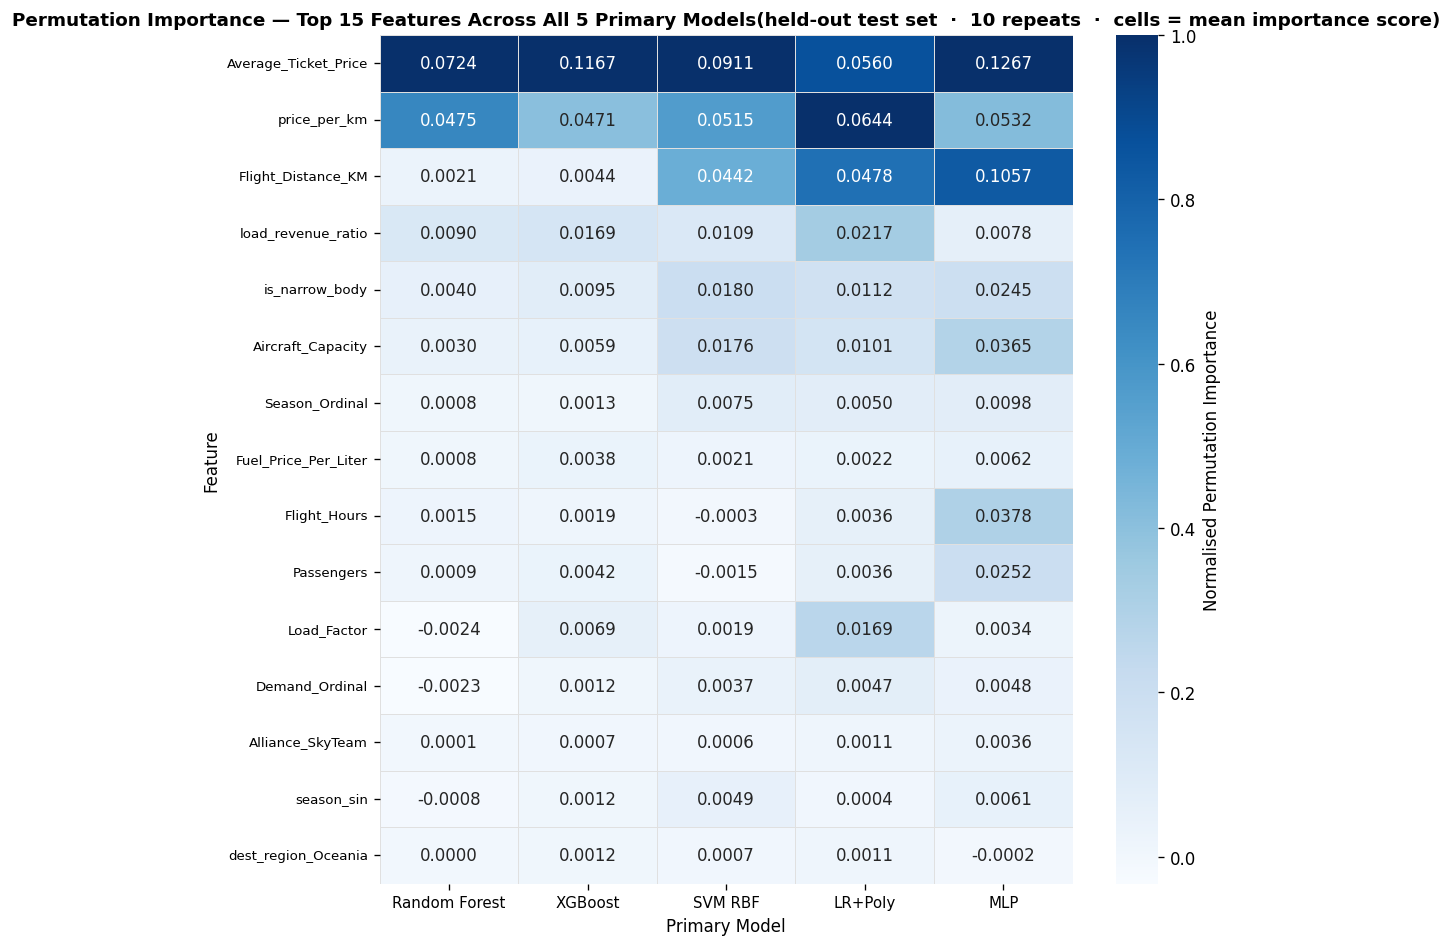

Saved: group_perm_importance_heatmap.png


In [11]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json as _json
from sklearn.inspection import permutation_importance
from pathlib import Path

PROC_DIR = BASE / "processed_data"

# ── Load BOTH scaled and raw test sets ───────────────────────────────────────
_X_scaled = pd.read_csv(PROC_DIR / 'X_test_scaled.csv')
_X_raw    = pd.read_csv(PROC_DIR / 'X_test.csv')
y_arr     = pd.read_csv(PROC_DIR / 'y_test.csv').squeeze().values

with open(PROC_DIR / 'feature_names.json') as _f:
    _feat_names = _json.load(_f)

_cols = [c for c in _feat_names if c in _X_scaled.columns]
_X_scaled_arr = _X_scaled[_cols].values
_X_raw_arr    = _X_raw[_cols].values
print(f"Test set: {_X_scaled_arr.shape[0]} rows x {len(_cols)} features")

model_pkl_map = {
    'Random Forest' : M1_DIR / 'best_rf_gokulkrishna.pkl',
    'XGBoost'       : M2_DIR / 'best_xgb_joel.pkl',
    'SVM RBF'       : M3_DIR / 'best_svm_apprajit.pkl',
    'LR+Poly'       : M4_DIR / 'best_lrpoly_afzal.pkl',
    'MLP'           : M5_DIR / 'best_mlp_vino.pkl',
}
_model_input = {
    'Random Forest' : _X_raw_arr,
    'XGBoost'       : _X_raw_arr,
    'SVM RBF'       : _X_scaled_arr,
    'LR+Poly'       : _X_scaled_arr,
    'MLP'           : _X_scaled_arr,
}

perm_results = {}
for _mname, _pkl_path in model_pkl_map.items():
    if not _pkl_path.exists():
        print(f'  WARNING: Missing pkl — {_pkl_path}')
        continue
    try:
        with open(_pkl_path, 'rb') as _fh:
            _model = pickle.load(_fh)
    except Exception as _load_err:
        print(f'  SKIP {_mname}: pkl load failed ({_load_err})')
        continue
    _X_use = _model_input[_mname]
    print(f'  Computing permutation importance: {_mname} ...')
    _r = permutation_importance(
        _model, _X_use, y_arr,
        n_repeats=10, scoring='f1', random_state=42, n_jobs=-1
    )
    perm_results[_mname] = _r.importances_mean
    from sklearn.metrics import f1_score as _f1
    _proba = _model.predict_proba(_X_use)[:, 1]
    _f1_val = _f1(y_arr, (_proba >= 0.5).astype(int))
    print(f'    Baseline F1 @ 0.50: {_f1_val:.4f}')

print(f'Done — {len(perm_results)} models processed.')

if perm_results:
    _imp_df = pd.DataFrame(perm_results, index=_cols)
    _ranks     = _imp_df.rank(ascending=False)
    _mean_rank = _ranks.mean(axis=1)
    _top15     = _mean_rank.nsmallest(15).index.tolist()
    _imp_top   = _imp_df.loc[_top15]

    _imp_norm = _imp_top.copy()
    for _col in _imp_norm.columns:
        _mx = _imp_norm[_col].max()
        if _mx > 0:
            _imp_norm[_col] = _imp_norm[_col] / _mx

    fig, ax = plt.subplots(figsize=(9, 8), dpi=120)
    sns.heatmap(
        _imp_norm,
        annot=_imp_top.round(4),
        fmt='.4f',
        cmap='Blues',
        linewidths=0.4,
        linecolor='#e0e0e0',
        ax=ax,
        cbar_kws={'label': 'Normalised Permutation Importance'}
    )
    ax.set_title(
        'Permutation Importance — Top 15 Features Across All 5 Primary Models'
        '(held-out test set  ·  10 repeats  ·  cells = mean importance score)',
        fontweight='bold', fontsize=11
    )
    ax.set_xlabel('Primary Model', fontsize=10)
    ax.set_ylabel('Feature', fontsize=10)
    ax.tick_params(axis='x', labelsize=9)
    ax.tick_params(axis='y', labelsize=8)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'group_perm_importance_heatmap.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: group_perm_importance_heatmap.png')
else:
    print('No permutation results — ensure all member pkl files exist.')

## Section 13 — F1-Score vs Decision Threshold (All Primary Models)

F1-score as the classification threshold is swept from 0.10 to 0.90 on the held-out test set.
Each model is one coloured line; the optimal threshold (peak F1) is marked with a filled dot.
The SVM's peak shifts right, reflecting its high-precision, lower-recall profile.

  Random Forest: best threshold = 0.42  F1 = 0.9376
  XGBoost: best threshold = 0.48  F1 = 0.9350
  SVM RBF: best threshold = 0.54  F1 = 0.9339
  LR+Poly: best threshold = 0.58  F1 = 0.9346
  MLP: best threshold = 0.48  F1 = 0.9381


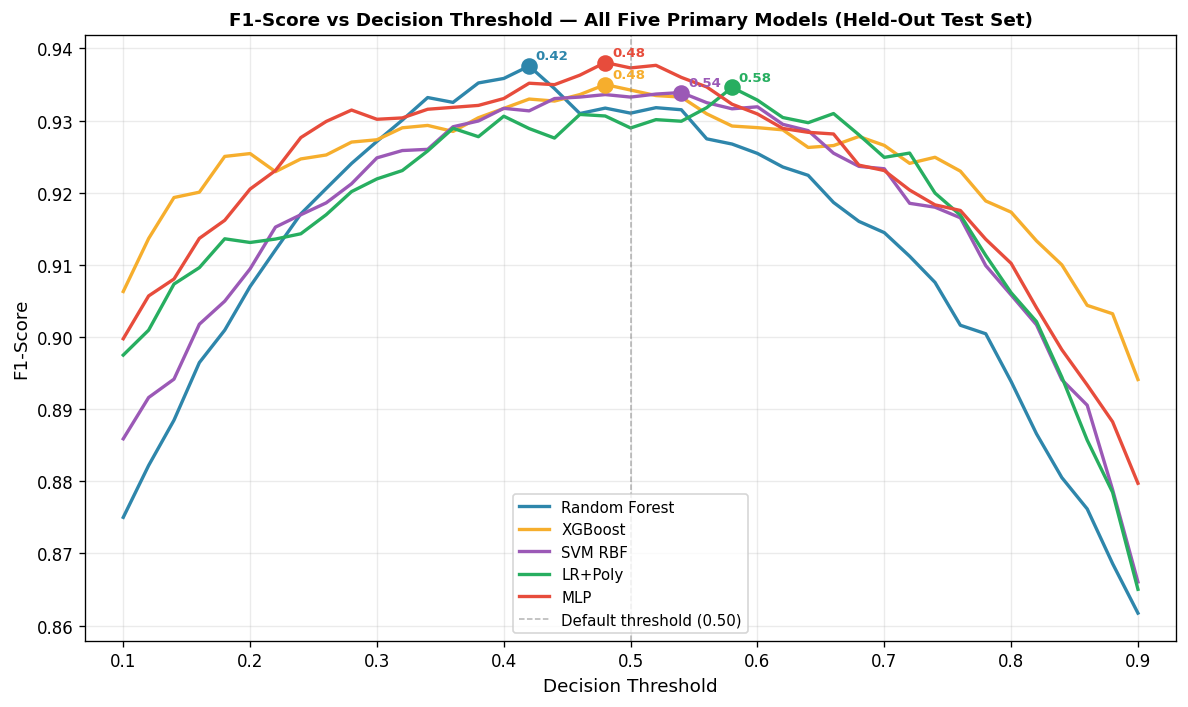

Saved: group_threshold_comparison.png


In [12]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import f1_score as _f1_score

_thresholds = np.arange(0.10, 0.91, 0.02)

threshold_results = {}
for _mname, _pkl_path in model_pkl_map.items():
    if not _pkl_path.exists():
        print(f'  WARNING: Missing pkl — {_pkl_path}')
        continue
    try:
        with open(_pkl_path, 'rb') as _fh:
            _model = pickle.load(_fh)
    except Exception as _load_err:
        print(f'  SKIP {_mname}: pkl load failed ({_load_err})')
        continue
    _X_use = _model_input[_mname]
    _proba = _model.predict_proba(_X_use)[:, 1]
    _f1s = [
        _f1_score(y_arr, (_proba >= _t).astype(int), zero_division=0)
        for _t in _thresholds
    ]
    threshold_results[_mname] = _f1s
    _best_t = _thresholds[int(np.argmax(_f1s))]
    print(f'  {_mname}: best threshold = {_best_t:.2f}  F1 = {max(_f1s):.4f}')

if threshold_results:
    fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

    for _mname, _f1s in threshold_results.items():
        _color = MODEL_COLORS.get(_mname, '#95A5A6')
        ax.plot(_thresholds, _f1s, label=_mname, color=_color, lw=2)
        _best_idx = int(np.argmax(_f1s))
        ax.scatter(_thresholds[_best_idx], _f1s[_best_idx],
                   color=_color, s=80, zorder=5)
        ax.annotate(
            f'{_thresholds[_best_idx]:.2f}',
            (_thresholds[_best_idx], _f1s[_best_idx]),
            textcoords='offset points', xytext=(4, 4),
            fontsize=8, color=_color, fontweight='bold'
        )

    ax.axvline(0.5, color='gray', ls='--', lw=0.9, alpha=0.6,
               label='Default threshold (0.50)')
    ax.set_xlabel('Decision Threshold', fontsize=11)
    ax.set_ylabel('F1-Score', fontsize=11)
    ax.set_title(
        'F1-Score vs Decision Threshold — All Five Primary Models (Held-Out Test Set)',
        fontweight='bold', fontsize=11
    )
    ax.legend(fontsize=9, loc='lower center')
    ax.grid(True, alpha=0.25)
    ax.set_xlim(0.07, 0.93)
    plt.tight_layout()
    plt.savefig(os.path.join(FIG_DIR, 'group_threshold_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: group_threshold_comparison.png')
else:
    print('No threshold results — ensure all member pkl files exist.')

## Section 14 — Save Group Summary

In [13]:
if not all_results.empty:
    all_results.to_csv(os.path.join(GROUP_DIR, 'group_all_model_comparison.csv'), index=False)
    print('Saved: group_all_model_comparison.csv')

    dt_mask = all_results['Model'].str.contains('Decision Tree', case=False)
    primary_df = all_results[~dt_mask].sort_values('F1_Score', ascending=False)
    primary_df.to_csv(os.path.join(GROUP_DIR, 'group_primary_models_ranked.csv'), index=False)
    print('Saved: group_primary_models_ranked.csv')

Saved: group_all_model_comparison.csv
Saved: group_primary_models_ranked.csv
